## Student Type Classification Using PISA Student Questionnaire Data (PCA + UMAP + Clustering)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.family'] = 'IPAexGothic'
import os
from tqdm import tqdm

pd.set_option('future.no_silent_downcasting', True)

In [2]:
ROOT_DIR = os.getcwd()

In [3]:
import pyreadstat

# SPSSのvalue labelsを適用せず、コード（1,2,3,4）で読み込む
#df, meta = pyreadstat.read_sav(os.path.join(ROOT_DIR, "CY07_MSU_STU_QQQ.sav"), apply_value_formats=False)
# 日本のデータ抽出
#df_tmp = df[df["CNT"] == "JPN"].copy()
# そのままCSVに保存
#df_tmp.to_csv(os.path.join(ROOT_DIR, "CY07_MSU_STU_QQQ_JPN_numeric.csv"), index=False)

df_student_original = pd.read_csv(os.path.join(ROOT_DIR, "CY07_MSU_STU_QQQ_JPN.csv"))
df_student_numeric = pd.read_csv(os.path.join(ROOT_DIR, "CY07_MSU_STU_QQQ_JPN_numeric.csv"))

In [4]:
df_school = pd.read_csv(os.path.join(ROOT_DIR, "df_school_val.csv"))

In [5]:
df_student_numeric = df_student_numeric.merge(
    df_school[["CNTSCHID", "cluster"]],
    on="CNTSCHID",
    how="left"
)
df_student_numeric = df_student_numeric.rename(columns={"cluster": "cluster_school"})

In [6]:
pd.set_option('display.max_info_columns', 10000)
print(df_student_numeric.shape)
df_student_numeric.info()

(6109, 1120)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6109 entries, 0 to 6108
Data columns (total 1120 columns):
 #     Column          Non-Null Count  Dtype  
---    ------          --------------  -----  
 0     CNTRYID         6109 non-null   float64
 1     CNT             6109 non-null   object 
 2     CNTSCHID        6109 non-null   float64
 3     CNTSTUID        6109 non-null   float64
 4     CYC             6109 non-null   object 
 5     NatCen          6109 non-null   int64  
 6     STRATUM         6109 non-null   object 
 7     SUBNATIO        6109 non-null   int64  
 8     OECD            6109 non-null   float64
 9     ADMINMODE       6109 non-null   float64
 10    LANGTEST_QQQ    6107 non-null   float64
 11    LANGTEST_COG    6109 non-null   float64
 12    LANGTEST_PAQ    0 non-null      float64
 13    BOOKID          6109 non-null   float64
 14    ST001D01T       6109 non-null   float64
 15    ST003D02T       6109 non-null   float64
 16    ST003D03T       6109 non-

In [7]:
# 有効でなさそうなカラム
cols_to_remove = [i for i in df_student_numeric.columns if i.startswith('W_FST')]
cols_to_remove2 = ["CNTRYID", "CNT", "CYC", "NatCen", "SUBNATIO", "OECD", "ADMINMODE", 
                   "LANGTEST_QQQ", "LANGTEST_COG",  "BOOKID", "OCOD1", "OCOD2", "OCOD3", 
                   "GRADE", "AGE", "PROGN", "COBN_S", "COBN_M", "COBN_F", "LANGN", "ISCEDL", 
                   "ISCEDD", "ISCEDO", "UNIT", "WVARSTRR"]

# カラムごとのユニーク値の数を取得
unique_counts = df_student_numeric.nunique()
# Yes/No（2値）のカラム
binary_cols = unique_counts[unique_counts == 2].index.tolist()

In [8]:
# 空文字を欠損として扱う
df_student_numeric = df_student_numeric.replace('', np.nan)

# 欠損率を計算
missing_ratio = df_student_numeric.isna().mean()

# 欠損率 5% 超のカラム
cols_over_threshold = list(missing_ratio[missing_ratio > 0.05].index)
# 削除するカラム
cols_to_drop = cols_to_remove + cols_to_remove2 + cols_over_threshold + binary_cols
df_student_numeric = df_student_numeric.drop(columns=cols_to_drop)

print(f"削除したカラム数: {len(cols_to_drop)}")
df_student_numeric.shape

削除したカラム数: 728


(6109, 402)

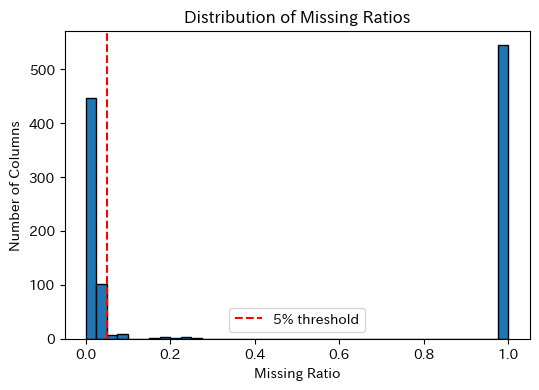

In [9]:
plt.figure(figsize=(6, 4))
plt.hist(missing_ratio, bins=40, edgecolor='black')
plt.xlabel('Missing Ratio')
plt.ylabel('Number of Columns')
plt.title('Distribution of Missing Ratios')
plt.axvline(0.05, color='red', linestyle='--', label='5% threshold')
plt.legend()
plt.show()


In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_student_numeric['STRATUM'] = le.fit_transform(df_student_numeric['STRATUM'].astype(str))
df_student_numeric['STRATUM'].unique()

array([0, 1, 2, 3])

In [11]:
cols_with_nan = df_student_numeric.columns[df_student_numeric.isna().any() | (df_student_numeric.eq('').any())]
print(len(cols_with_nan))

312


### PCA＋KNN による欠損値補完

In [12]:

import pandas as pd
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

pv_math = [f"PV{i}MATH" for i in range(1, 11)]
pv_read = [f"PV{i}READ" for i in range(1, 11)]
pv_science = [f"PV{i}SCIE" for i in range(1, 11)]

# ---------------------------------------------------------
# 0. PV列の定義（例：PV1〜PV10 × 3教科 = 30列）
# ---------------------------------------------------------
pv_cols = pv_math + pv_read + pv_science   # 30列

# ---------------------------------------------------------
# 1. PCA による次元圧縮（PV30 → 主成分3）
# ---------------------------------------------------------
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(df_student_numeric[pv_cols])   # shape: (n_samples, 3)

# PCA特徴量を df に追加（任意）
df_student_numeric["PC1"], df_student_numeric["PC2"], df_student_numeric["PC3"] = X_pca[:, 0], X_pca[:, 1], X_pca[:, 2]
# ---------------------------------------------------------
# 2. 欠損のある生徒の抽出
# ---------------------------------------------------------
target_cols = cols_with_nan   # 補完対象の312列

# 補完対象列のどこかに欠損がある生徒だけを集めたDataFrame
incomplete_df = df_student_numeric[df_student_numeric[target_cols].isnull().any(axis=1)].copy()
#欠損のある生徒の「元の行番号（インデックス）」取り出し
incomplete_idx = incomplete_df.index

# 欠損生徒の PCA 特徴量
# 欠損のある生徒だけに対応する PCA ベクトルを取り出す
# このincomplete_Xを「クエリ」として、近い生徒（近傍）を探す入力に使用する
incomplete_X = X_pca[incomplete_idx]

# ---------------------------------------------------------
# 3. 近傍探索（k=5）
# ---------------------------------------------------------
#PCA 空間上で近い生徒を探すためのモデル->近傍探索（k=5）
nn = NearestNeighbors(n_neighbors=6, metric="euclidean")
#全生徒の PCA 特徴量 X_pca を「近傍探索の対象データ」として登録
nn.fit(X_pca)

# indicesはPCA 行列 X_pca の “行番号（0-based の位置）”を取り出す。インデックスを取り出すわけではないの注意
distances, indices = nn.kneighbors(incomplete_X)

# ---------------------------------------------------------
# 4. 補完処理（近傍5人の平均で補完）
# ---------------------------------------------------------
for i, idx_list in tqdm(enumerate(indices)):
    # 欠損のある生徒の index
    row_index = incomplete_idx[i]
    # 元データから欠損行を取得
    #row = incomplete_df.loc[row_index] -> 正しく動作しない場合がある
    row = df_student_numeric.loc[row_index]

    # 欠損のあるカラム名抽出
    mask = row.isna() | (row.eq(''))
    cols_nan = row.index[mask]
    
    # 近傍5人のデータ（iloc が正しい）
    neighbors = df_student_numeric.iloc[idx_list][cols_nan]
    
    # 欠損カラムだけ補完
    df_student_numeric.loc[row_index, cols_nan] = neighbors.mean()

df_student_numeric = df_student_numeric.drop(columns=['PC1', 'PC2', 'PC3'])
print("PCA＋KNN による欠損補完が完了しました。")


3450it [00:08, 385.71it/s]

PCA＋KNN による欠損補完が完了しました。


In [13]:
df_student_numeric.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6109 entries, 0 to 6108
Data columns (total 402 columns):
 #    Column          Non-Null Count  Dtype  
---   ------          --------------  -----  
 0    CNTSCHID        6109 non-null   float64
 1    CNTSTUID        6109 non-null   float64
 2    STRATUM         6109 non-null   int32  
 3    ST001D01T       6109 non-null   float64
 4    ST003D02T       6109 non-null   float64
 5    ST005Q01TA      6109 non-null   float64
 6    ST011D17TA      6109 non-null   int64  
 7    ST011D18TA      6109 non-null   int64  
 8    ST011D19TA      6109 non-null   int64  
 9    ST012Q01TA      6109 non-null   float64
 10   ST012Q02TA      6109 non-null   float64
 11   ST012Q03TA      6109 non-null   float64
 12   ST012Q05NA      6109 non-null   float64
 13   ST012Q06NA      6109 non-null   float64
 14   ST012Q07NA      6109 non-null   float64
 15   ST012Q08NA      6109 non-null   float64
 16   ST012Q09NA      6109 non-null   float64
 17   ST013Q01TA  

### statsmodels を使った ICC（学校レベル）の計算例
#### MATH PV1〜PV10 を使った ICC の平均

In [14]:
import statsmodels.formula.api as smf
def calc_icc(df, pv_prefix, group="CNTSCHID"):
    #print(pv_prefix[:2], pv_prefix[2:])
    pv_prefix_pv = pv_prefix[:2]
    pv_prefix_sub = pv_prefix[2:]
    icc_list = []
    for i in range(1, 11):  # PV1〜PV10
        #pv = f"{pv_prefix}{i}"
        pv = f"{pv_prefix_pv}{i}{pv_prefix_sub}"
        #print(pv)
        model = smf.mixedlm(f"{pv} ~ 1", df, groups=df[group])
        result = model.fit()
        var_school = result.cov_re.iloc[0, 0]
        var_resid = result.scale
        icc = var_school / (var_school + var_resid)
        icc_list.append(icc)
    return np.mean(icc_list), icc_list

# 例：MATH の ICC
icc_math_mean, icc_math_list = calc_icc(df_student_numeric, "PV1MATH".replace("1",""))

print("MATH ICC mean:", icc_math_mean)
print("MATH ICC list:", icc_math_list)

MATH ICC mean: 0.42880838698705415
MATH ICC list: [0.43156941967925627, 0.4205290713073241, 0.4266040854404332, 0.415363421407881, 0.4302960137878692, 0.42617009284816576, 0.4290442696110862, 0.43328024048371266, 0.4350023151038301, 0.440224940200983]


### 8科目すべてのICCを計算

In [15]:
pv_domains = ["MATH", "READ", "SCIE", "RCLI", "RCUN", "RCER", "RTSN", "RTML"]

icc_results = {}

for domain in tqdm(pv_domains):
    mean_icc, icc_list = calc_icc(df_student_numeric, f"PV1{domain}".replace("1",""))
    icc_results[domain] = mean_icc

print(icc_results)


100%|███████████████| 8/8 [01:16<00:00,  9.57s/it]

{'MATH': 0.42880838698705415, 'READ': 0.3897479842862238, 'SCIE': 0.40078413605055463, 'RCLI': 0.36725143036755215, 'RCUN': 0.375641025401192, 'RCER': 0.3927176881232157, 'RTSN': 0.38684178429615856, 'RTML': 0.37977902610851344}


### 分散成分の可視化（PV を平均した ICC）

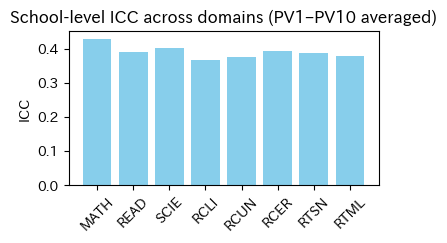

In [16]:
plt.figure(figsize=(4, 2))
plt.bar(icc_results.keys(), icc_results.values(), color="skyblue")
plt.ylabel("ICC")
plt.title("School-level ICC across domains (PV1–PV10 averaged)")
plt.xticks(rotation=45)
plt.show()

### 混合モデルの残差を PVごとに取り出す

In [17]:
def extract_residuals(df, pv_prefix, group="CNTSCHID"):
    residuals = pd.DataFrame(index=df.index)
    pv_prefix_pv = pv_prefix[:2]
    pv_prefix_sub = pv_prefix[2:]
    
    for i in range(1, 11):
        pv = f"{pv_prefix_pv}{i}{pv_prefix_sub}"
        model = smf.mixedlm(f"{pv} ~ 1", df, groups=df[group])
        result = model.fit()
        residuals[pv] = result.resid  # 残差を保存
    
    return residuals

# 例：MATH の PV 残差
resid_math = extract_residuals(df_student_numeric, "PV1MATH".replace("1",""))

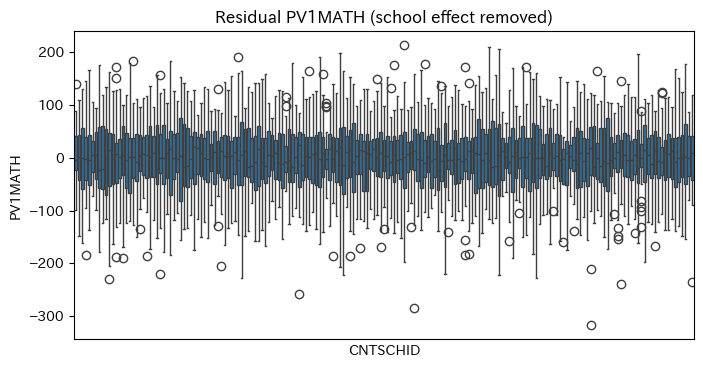

In [18]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_student_numeric["CNTSCHID"], y=resid_math["PV1MATH"])
plt.xticks([], [])
plt.title("Residual PV1MATH (school effect removed)")
plt.show()

### 全科目について残差を取り出す

In [19]:
def extract_pv_residuals(df, pv_prefix, group="CNTSCHID"):
    residuals = pd.DataFrame(index=df.index)
    pv_prefix_pv = pv_prefix[:2]
    pv_prefix_sub = pv_prefix[2:]
    for i in range(1, 11):
        pv = f"{pv_prefix_pv}{i}{pv_prefix_sub}"
        model = smf.mixedlm(f"{pv} ~ 1", df, groups=df[group])
        result = model.fit()
        residuals[pv] = result.resid  # 残差を保存
    
    return residuals

df_pv_resid = pd.DataFrame(index=df_student_numeric.index)
for domain in tqdm(pv_domains):
    df_tmp = extract_pv_residuals(df_student_numeric, f"PV{domain}")
    df_pv_resid = pd.concat([df_pv_resid, df_tmp], axis=1)

df_pv_resid.shape

100%|███████████████| 8/8 [01:20<00:00, 10.01s/it]


(6109, 80)

In [20]:
df_pv_resid

,PV1MATH,PV2MATH,PV3MATH,PV4MATH,PV5MATH,PV6MATH,PV7MATH,PV8MATH,PV9MATH,PV10MATH,...,PV1RTML,PV2RTML,PV3RTML,PV4RTML,PV5RTML,PV6RTML,PV7RTML,PV8RTML,PV9RTML,PV10RTML
0,59.80217,35.924348,26.479546,-26.180401,75.510485,21.178495,20.028386,34.536038,48.537306,21.853647,...,74.141099,44.695906,18.451417,19.151618,-8.340595,74.642375,37.445427,39.760034,12.505103,86.565656
1,-63.38683,51.219348,31.197546,37.559599,16.366485,-37.002505,-14.745614,-22.038962,-37.560694,-4.466353,...,-38.288901,-62.804094,-13.367583,-14.320382,-50.746595,-34.192625,11.706427,-62.820966,-49.069897,-76.504344
2,47.55917,-42.975652,62.360546,44.731599,-17.451515,41.126495,38.182386,33.091038,-41.873694,-50.054353,...,-25.229901,-39.730094,12.829417,-16.854382,14.944405,-6.952625,-11.167573,-0.503966,-29.588897,21.560656
3,-17.04783,-35.163652,5.037546,-8.456401,-18.906515,-35.379505,-49.104614,28.614038,13.989306,6.709647,...,59.644099,71.209906,13.511417,69.988618,38.883405,93.215375,89.367427,94.051034,73.906103,114.183656
4,37.03417,124.561348,-17.024454,82.945599,103.803485,20.526495,66.361386,24.972038,41.639306,9.204647,...,49.581099,79.429906,38.601417,127.376618,97.332405,75.646375,102.758427,58.635034,43.029103,100.027656
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6104,45.53898,38.776171,29.952487,25.240429,-2.499408,36.610746,31.029685,25.719377,-10.894256,26.785129,...,-30.773816,-1.487794,-4.624674,-26.083933,-48.511642,-31.303262,-60.767166,-32.874836,-33.946750,-57.313710
6105,2.77798,-26.919829,34.719487,-20.024571,28.034592,3.738746,4.637685,7.793377,-3.736256,13.763129,...,-57.127816,-35.373794,-83.282674,-68.269933,-58.656642,6.299738,-30.550166,-43.740836,-97.020750,-46.810710
6106,-18.49602,-33.351829,24.822487,2.012429,-13.082408,10.524746,-14.401315,40.021377,46.998744,-9.409871,...,137.573184,30.186206,134.715326,84.765067,87.220358,68.271738,108.216834,96.981164,81.267250,69.542290
6107,-64.56402,-95.843829,-49.211513,-151.096571,-84.172408,-28.348254,-72.603315,-108.753623,-127.493256,-133.214871,...,-39.842816,-10.096794,-33.330674,-51.062933,-20.426642,-46.936262,-65.276166,-48.743836,-21.246750,-21.179710


### 質問タイプごとにカラムを取り出す

In [21]:
Q_IC_cols = [i for i in df_student_numeric.columns if i.startswith('IC')]
Q_ST_cols = [i for i in df_student_numeric.columns if i.startswith('ST')]
Q_PV_cols = [i for i in df_student_numeric.columns if i.startswith('PV')]

In [22]:
print(f"Q_IC:{len(Q_IC_cols)}")
print(f"Q_ST:{len(Q_ST_cols)}")
print(f"Q_PV:{len(Q_PV_cols)}")

Q_IC:111
Q_ST:163
Q_PV:80


In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import numpy as np

# --- 1. PV と PV以外を分割 ---
non_pv_cols = [c for c in df_student_numeric.columns if c not in Q_PV_cols]
df_non_pv = df_student_numeric[non_pv_cols]
df_pv = df_pv_resid

# --- 2. PV以外を標準化 ---
X_non_pv = StandardScaler().fit_transform(df_non_pv)

# --- 3. PV以外で PCA（15次元） ---
pca_non_pv = PCA(n_components=15, random_state=42)
X_pca_non_pv = pca_non_pv.fit_transform(X_non_pv)

# --- 4. PV を PCA（8次元） ---
pca_pv = PCA(n_components=8, random_state=42)
X_pca_pv = pca_pv.fit_transform(df_pv.values)

# --- 5. 2つの PCA 結果を結合 ---
X_final = np.concatenate([X_pca_non_pv, X_pca_pv], axis=1)

# --- 6. KMeans（5クラスタ） ---
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_final)


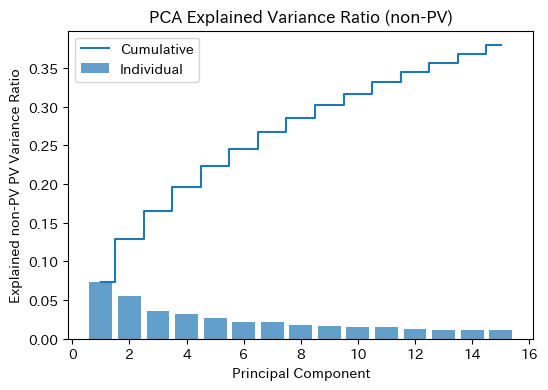

In [24]:
# 寄与率
explained_non_pv = pca_non_pv.explained_variance_ratio_

plt.figure(figsize=(6,4))
plt.bar(range(1, len(explained_non_pv)+1), explained_non_pv, alpha=0.7, label="Individual")
plt.step(range(1, len(explained_non_pv)+1), np.cumsum(explained_non_pv), where='mid', label="Cumulative")
plt.xlabel("Principal Component")
plt.ylabel("Explained non-PV PV Variance Ratio")
plt.title("PCA Explained Variance Ratio (non-PV)")
plt.legend()
plt.show()

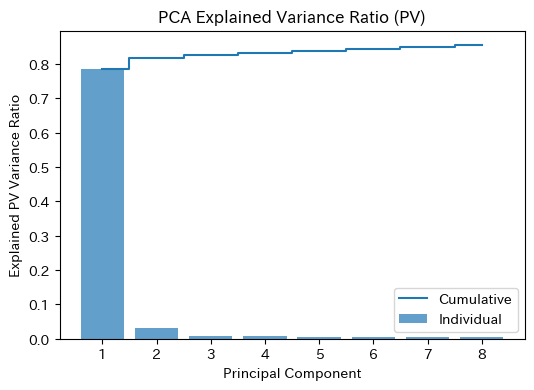

In [25]:
explained_pv = pca_pv.explained_variance_ratio_

plt.figure(figsize=(6,4))
plt.bar(range(1, len(explained_pv)+1), explained_pv, alpha=0.7, label="Individual")
plt.step(range(1, len(explained_pv)+1), np.cumsum(explained_pv), where='mid', label="Cumulative")
plt.xlabel("Principal Component")
plt.ylabel("Explained PV Variance Ratio")
plt.title("PCA Explained Variance Ratio (PV)")
plt.legend()
plt.show()

In [26]:
print(np.cumsum(explained_non_pv))
print(np.cumsum(explained_pv))

[0.07352718 0.12922209 0.16495427 0.19671582 0.2238781  0.24580831
 0.26709691 0.28539297 0.30198512 0.31692501 0.33153183 0.34457213
 0.35628472 0.36786875 0.3793037 ]
[0.78599444 0.81723172 0.826108   0.83370702 0.83937966 0.84460426
 0.84970716 0.85464398]


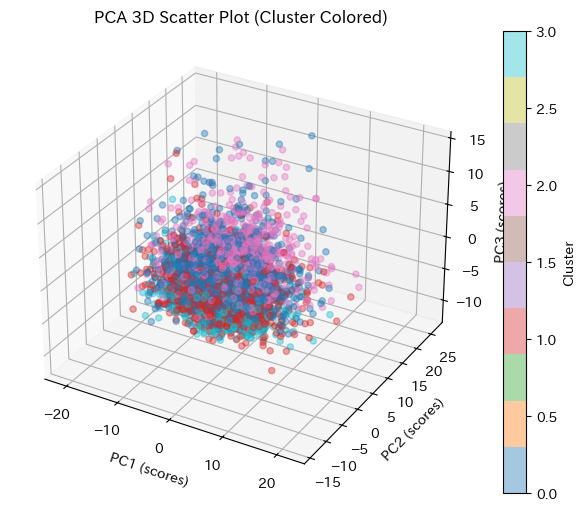

In [27]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca_non_pv[:, 0],   # PC1
    X_pca_non_pv[:, 1],   # PC2
    X_pca_non_pv[:, 2],   # PC3
    c=clusters, cmap="tab10", alpha=0.4
)

ax.set_xlabel("PC1 (scores)")
ax.set_ylabel("PC2 (scores)")
ax.set_zlabel("PC3 (scores)")
ax.set_title("PCA 3D Scatter Plot (Cluster Colored)")

fig.colorbar(scatter, label="Cluster")
plt.show()


### パラメータ探索（UMAP）

In [28]:
from sklearn.metrics import silhouette_score
import umap
from sklearn.cluster import KMeans

def evaluate_umap_params(X, n_clusters=5):
    candidates = []
    for n_neighbors in [15, 30, 50, 100]:
        for min_dist in [0.0, 0.1, 0.3]:
            reducer = umap.UMAP(
                n_neighbors=n_neighbors,
                min_dist=min_dist,
                n_components=2,
                random_state=42,
                n_jobs=1
            )
            X_emb = reducer.fit_transform(X)
            labels = KMeans(n_clusters=n_clusters, random_state=42, n_init=10).fit_predict(X_emb)
            score = silhouette_score(X_emb, labels)
            candidates.append((score, n_neighbors, min_dist))
            print(score, n_neighbors, min_dist)

    return sorted(candidates, reverse=True)

scores = evaluate_umap_params(X_final, n_clusters=4)

0.50273573 15 0.0
0.48937604 15 0.1
0.4712684 15 0.3
0.4988161 30 0.0
0.49567062 30 0.1
0.4759595 30 0.3
0.50807166 50 0.0
0.49681786 50 0.1
0.47816497 50 0.3
0.5097762 100 0.0
0.49885568 100 0.1
0.48162523 100 0.3


### エルボー法

In [29]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

def elbow_method(X, max_k=10):
    inertias = []
    for k in range(2, max_k+1):
        km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
        inertias.append(km.inertia_)

    plt.plot(range(2, max_k+1), inertias, marker='o')
    plt.xlabel("k")
    plt.ylabel("Inertia")
    plt.title("Elbow Method")
    plt.show()


### シルエットスコア

In [30]:
from sklearn.metrics import silhouette_score

def silhouette_method(X, max_k=10):
    scores = []
    for k in range(2, max_k+1):
        labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X)
        score = silhouette_score(X, labels)
        scores.append(score)
        print(k, score)

    plt.plot(range(2, max_k+1), scores, marker='o')
    plt.xlabel("k")
    plt.ylabel("Silhouette Score")
    plt.title("Silhouette Method")
    plt.show()


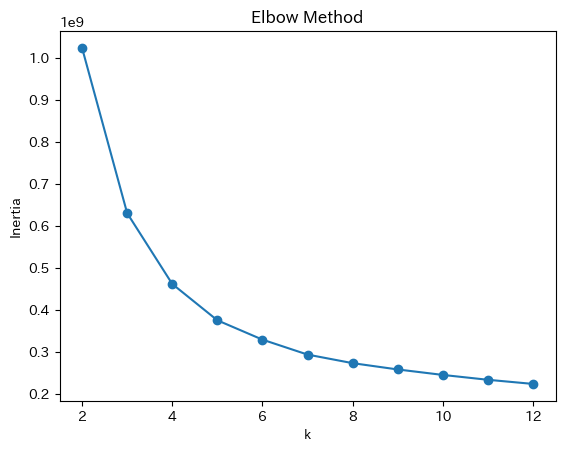

2 0.46432617876590615
3 0.4060837669526541
4 0.3614676019038077
5 0.3257902271059483
6 0.28673178063869986
7 0.2714756077075846
8 0.2365908268353802
9 0.21778946702198768
10 0.21393137299668352
11 0.1989936913345593
12 0.19812139312808458


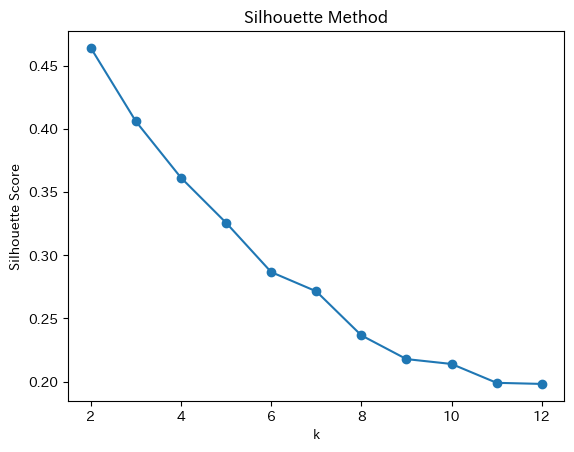

In [31]:
elbow_method(X_final, max_k=12)
silhouette_method(X_final, max_k=12)

### UMAP → K‑means 実行

In [32]:
import umap
from sklearn.metrics import silhouette_score

# --- 1. UMAP による次元削減 ---
# n_neighbors と min_dist は後で調整可能
reducer = umap.UMAP(
    #n_neighbors=30,
    n_neighbors=50,
    min_dist=0.0,
    n_components=2,   # KMeans 用の埋め込み次元
    random_state=42,
    n_jobs=1
)

X_umap = reducer.fit_transform(X_final)

print("UMAP embedding shape:", X_umap.shape)

# --- 2. KMeans によるクラスタリング ---
k = 4  # クラスタ数（後でエルボー法やシルエットで最適化）
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_umap)

# --- 3. シルエットスコアの計算 ---
sil_score = silhouette_score(X_umap, clusters)
print("Silhouette Score:", sil_score)

# --- 4. 元データにクラスタラベルを付与 ---
df_student_numeric['cluster'] = clusters

# --- 5. クラスタ平均を作成（レーダーチャート用） ---
df_means = df_student_numeric.groupby('cluster').mean()


UMAP embedding shape: (6109, 2)
Silhouette Score: 0.50807166


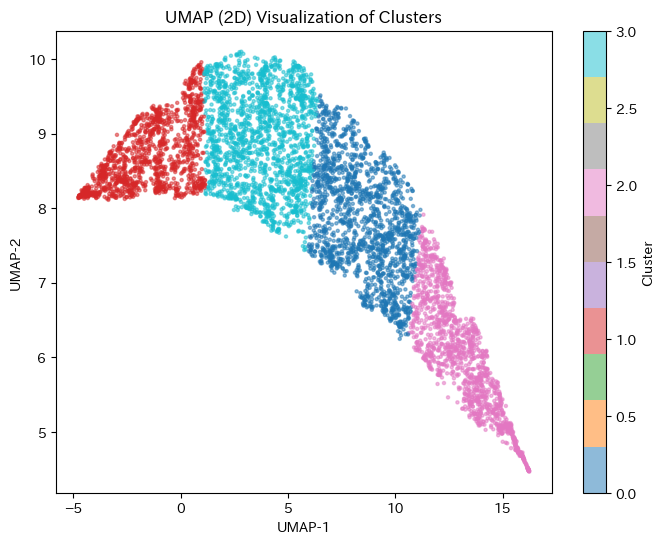

In [33]:
# --- 散布図でクラスタを可視化 ---
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=clusters,        # KMeansのクラスタラベル
    cmap='tab10',
    s=5,
    alpha=0.5
)

plt.colorbar(scatter, label="Cluster")
plt.title("UMAP (2D) Visualization of Clusters")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()


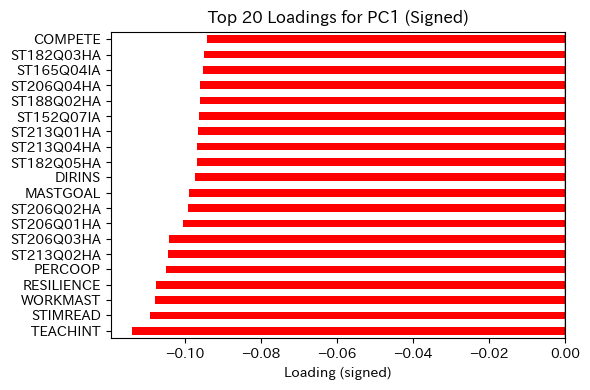

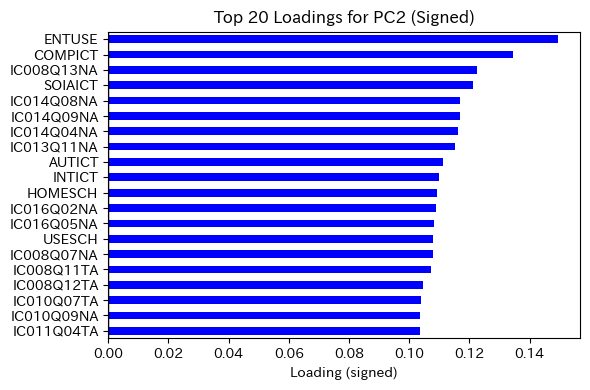

In [34]:
# --- PCA loading の取得 ---
loadings_non_pv = pd.DataFrame(
    pca_non_pv.components_.T,
    index=non_pv_cols,
    columns=[f"PC{i+1}" for i in range(15)]
)

loadings_pv = pd.DataFrame(
    pca_pv.components_.T,
    index=Q_PV_cols,
    columns=[f"PC{i+1}" for i in range(15, 23)]
)

# 結合（23次元）
loadings_all = pd.concat([loadings_non_pv, loadings_pv], axis=0)

# PC1 と PC2 の loading
pc1 = loadings_all["PC1"]
pc2 = loadings_all["PC2"]

# 上位20件（絶対値で抽出）
top20_pc1 = pc1.reindex(pc1.abs().sort_values(ascending=False).head(20).index)
top20_pc2 = pc2.reindex(pc2.abs().sort_values(ascending=False).head(20).index)

# --- 可視化関数（符号付き） ---
def plot_signed_loadings(series, title):
    plt.figure(figsize=(6, 4))

    # 並び替え
    series_sorted = series.sort_values()

    # 並び替え後の値に基づいて色を決定
    colors = ["blue" if v > 0 else "red" for v in series_sorted]

    series_sorted.plot(kind="barh", color=colors)
    plt.axvline(0, color="black", linewidth=1)
    plt.title(title)
    plt.xlabel("Loading (signed)")
    plt.tight_layout()
    plt.show()

# --- プロット ---
plot_signed_loadings(top20_pc1, "Top 20 Loadings for PC1 (Signed)")
plot_signed_loadings(top20_pc2, "Top 20 Loadings for PC2 (Signed)")


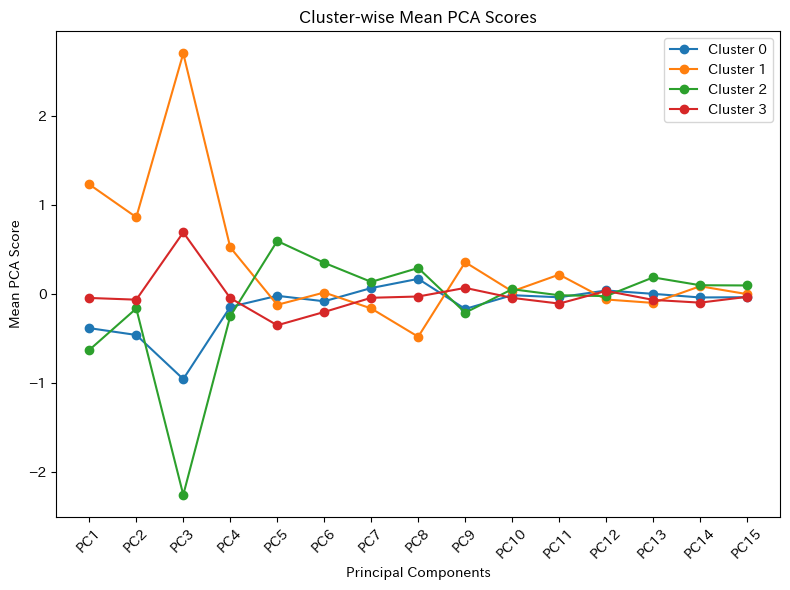

In [35]:
# PCAスコアをDataFrame化
df_pca_scores = pd.DataFrame(
    X_final,
    columns=[f"PC{i+1}" for i in range(X_final.shape[1])]
)
df_pca_scores["cluster"] = clusters

# クラスタごとの平均
cluster_pca_mean = df_pca_scores.groupby("cluster").mean()

# 可視化
plt.figure(figsize=(8, 6))
#pcs = cluster_pca_mean.columns  # PC1〜PC23
pcs = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10',
       'PC11', 'PC12', 'PC13', 'PC14', 'PC15']

for c in cluster_pca_mean.index:
    #plt.plot(pcs, cluster_pca_mean.loc[c], marker="o", label=f"Cluster {c}")
    plt.plot(pcs, cluster_pca_mean.iloc[c, :15], marker="o", label=f"Cluster {c}")

plt.xticks(rotation=45)
plt.xlabel("Principal Components")
plt.ylabel("Mean PCA Score")
plt.title("Cluster-wise Mean PCA Scores")
plt.legend()
plt.tight_layout()
plt.show()



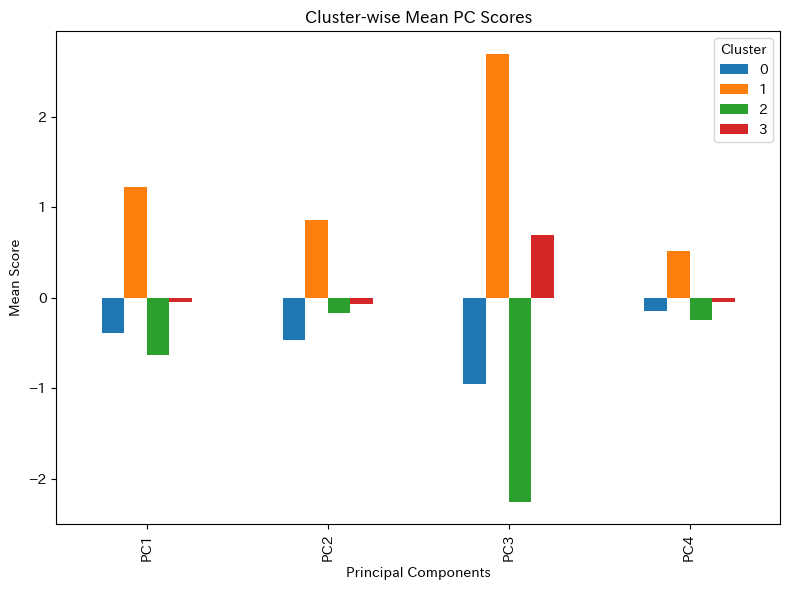

In [36]:
cluster_pca_mean.iloc[:, :4].T.plot(kind="bar", figsize=(8,6))
plt.title("Cluster-wise Mean PC Scores")
plt.xlabel("Principal Components")
plt.ylabel("Mean Score")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

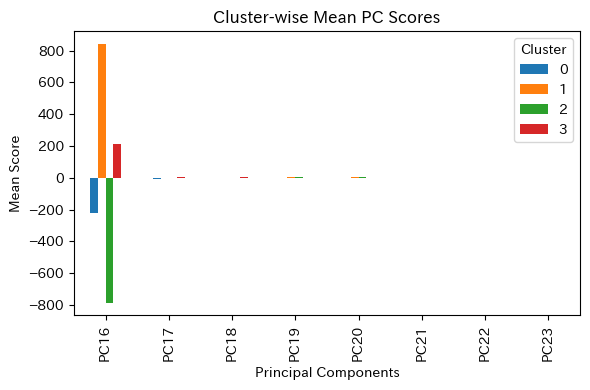

In [37]:
cluster_pca_mean.iloc[:, 15:].T.plot(kind="bar", figsize=(6,4))
plt.title("Cluster-wise Mean PC Scores")
plt.xlabel("Principal Components")
plt.ylabel("Mean Score")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

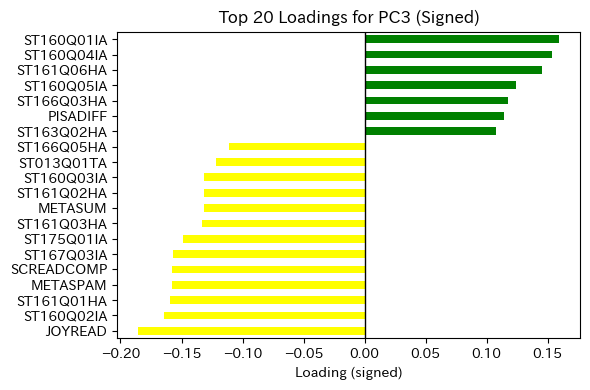

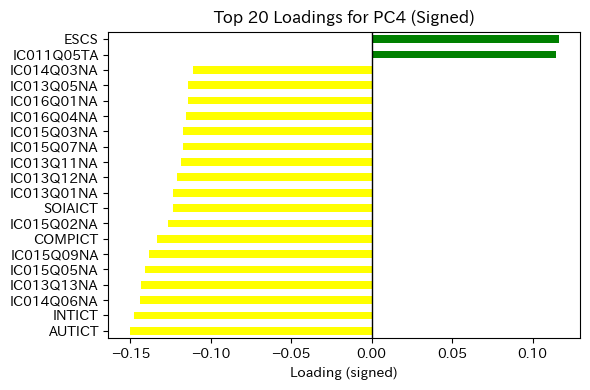

In [38]:
# PC3 と PC4 の loading
pc3 = loadings_all["PC3"]
pc4 = loadings_all["PC4"]

# 上位20件（絶対値で抽出）
top20_pc3 = pc3.reindex(pc3.abs().sort_values(ascending=False).head(20).index)
top20_pc4 = pc4.reindex(pc4.abs().sort_values(ascending=False).head(20).index)

def plot_signed_loadings(series, title):
    plt.figure(figsize=(6, 4))

    # 並び替え
    series_sorted = series.sort_values()

    # 並び替え後の値に基づいて色を決定
    colors = ["green" if v > 0 else "yellow" for v in series_sorted]

    series_sorted.plot(kind="barh", color=colors)
    plt.axvline(0, color="black", linewidth=1)
    plt.title(title)
    plt.xlabel("Loading (signed)")
    plt.tight_layout()
    plt.show()

# --- プロット ---
plot_signed_loadings(top20_pc3, "Top 20 Loadings for PC3 (Signed)")
plot_signed_loadings(top20_pc4, "Top 20 Loadings for PC4 (Signed)")

In [39]:
top20_pc1_idx = pc1.abs().sort_values(ascending=False).head(20).index
df_pc1 = loadings_all.loc[top20_pc1_idx].sort_values("PC1")
top20_pc2_idx = pc2.abs().sort_values(ascending=False).head(20).index
df_pc2 = loadings_all.loc[top20_pc2_idx].sort_values("PC1")
top20_pc3_idx = pc3.abs().sort_values(ascending=False).head(20).index
df_pc3 = loadings_all.loc[top20_pc3_idx].sort_values("PC1")
top20_pc4_idx = pc4.abs().sort_values(ascending=False).head(20).index
df_pc4 = loadings_all.loc[top20_pc4_idx].sort_values("PC1")

pc1_cols = list(df_pc1.index)
pc2_cols = list(df_pc2.index)
pc3_cols = list(df_pc3.index)
pc4_cols = list(df_pc4.index)

print("=====PC1=====")
for col in pc1_cols:
    print(df_means[col])
    print()

print("=====PC2=====")
for col in pc2_cols:
    print(df_means[col])
    print()

print("=====PC3=====")
for col in pc3_cols:
    print(df_means[col])
    print()

print("=====PC4=====")
for col in pc4_cols:
    print(df_means[col])
    print()

=====PC1=====
cluster
0   -0.224511
1   -0.369530
2   -0.178010
3   -0.197894
Name: TEACHINT, dtype: float64

cluster
0    0.182892
1   -0.001815
2    0.160113
3    0.153894
Name: STIMREAD, dtype: float64

cluster
0   -0.122716
1   -0.114530
2   -0.180588
3   -0.056171
Name: WORKMAST, dtype: float64

cluster
0   -0.652112
1   -0.551304
2   -0.676930
3   -0.588073
Name: RESILIENCE, dtype: float64

cluster
0    0.150013
1    0.065821
2    0.063903
3    0.151692
Name: PERCOOP, dtype: float64

cluster
0    2.535054
1    2.421222
2    2.530174
3    2.551655
Name: ST213Q02HA, dtype: float64

cluster
0    2.772912
1    2.729924
2    2.728884
3    2.787939
Name: ST206Q03HA, dtype: float64

cluster
0    2.733652
1    2.650035
2    2.662551
3    2.730211
Name: ST206Q01HA, dtype: float64

cluster
0    2.795698
1    2.753588
2    2.738159
3    2.801247
Name: ST206Q02HA, dtype: float64

cluster
0   -0.277381
1   -0.337033
2   -0.340028
3   -0.280771
Name: MASTGOAL, dtype: float64

cluster
0    0.20

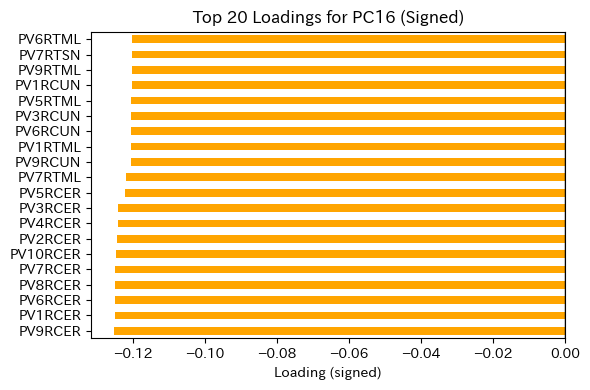

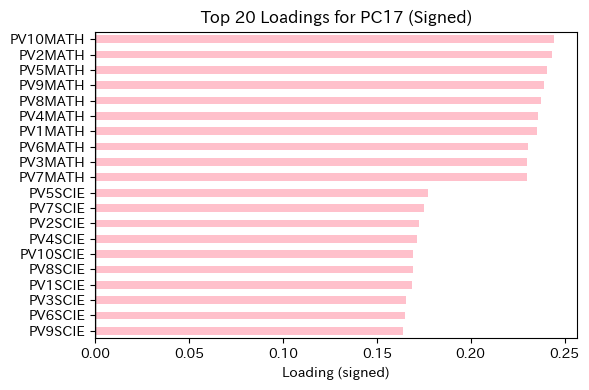

In [40]:
# PC16 と PC17 の loading
pc16 = loadings_all["PC16"]
pc17 = loadings_all["PC17"]

# 上位20件（絶対値で抽出）
top20_pc16 = pc16.reindex(pc16.abs().sort_values(ascending=False).head(20).index)
top20_pc17 = pc17.reindex(pc17.abs().sort_values(ascending=False).head(20).index)

def plot_signed_loadings(series, title):
    plt.figure(figsize=(6, 4))

    # 並び替え
    series_sorted = series.sort_values()

    # 並び替え後の値に基づいて色を決定
    colors = ["pink" if v > 0 else "orange" for v in series_sorted]

    series_sorted.plot(kind="barh", color=colors)
    plt.axvline(0, color="black", linewidth=1)
    plt.title(title)
    plt.xlabel("Loading (signed)")
    plt.tight_layout()
    plt.show()

# --- プロット ---
plot_signed_loadings(top20_pc16, "Top 20 Loadings for PC16 (Signed)")
plot_signed_loadings(top20_pc17, "Top 20 Loadings for PC17 (Signed)")

In [41]:
Q_PV_select = [sub for sub in Q_PV_cols if sub.endswith('MATH') or sub.endswith('READ') or sub.endswith('SCIE') \
              or sub.endswith('RCER') or sub.endswith('RCUN') or sub.endswith('RTML')]
#Q_PV_select

C:\Users\sea_s\AppData\Local\Temp\ipykernel_5296\486851080.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pv["PV_mean"] = df_pv.mean(axis=1)
C:\Users\sea_s\AppData\Local\Temp\ipykernel_5296\486851080.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pv["cluster"] = clusters


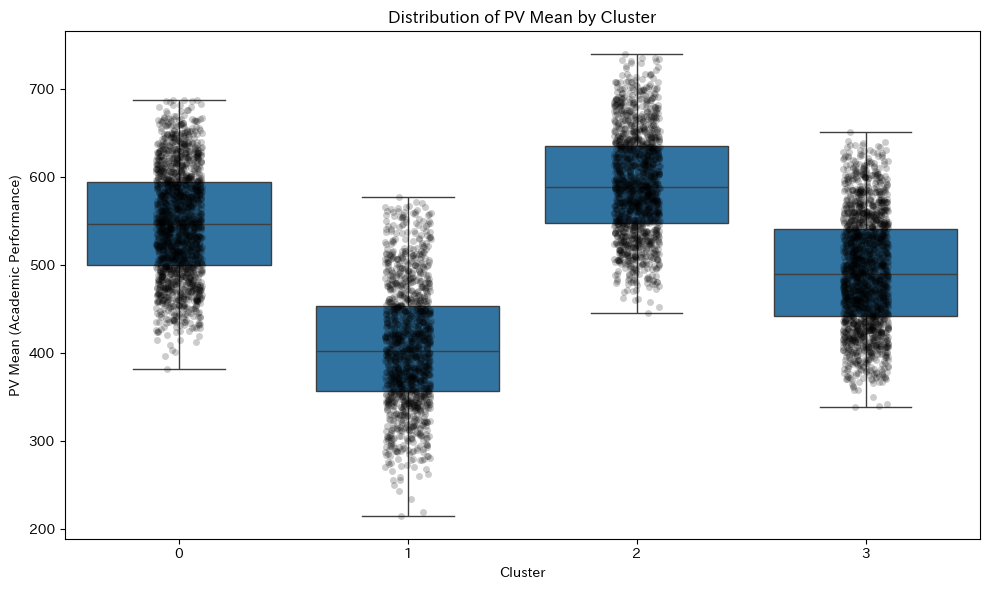

In [42]:
# PV の平均値を計算
#df_pv = df_student_numeric[Q_PV_cols]
df_pv = df_student_numeric[Q_PV_select]
df_pv["PV_mean"] = df_pv.mean(axis=1)

# クラスタラベルを付与
df_pv["cluster"] = clusters

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_pv, x="cluster", y="PV_mean")
sns.stripplot(data=df_pv, x="cluster", y="PV_mean", color="black", alpha=0.2)
plt.title("Distribution of PV Mean by Cluster")
plt.xlabel("Cluster")
plt.ylabel("PV Mean (Academic Performance)")
plt.tight_layout()
plt.show()


In [43]:
df_pv_means = df_means[pv_cols]
# --- 科目ごとの PV 列を抽出 ---
pv_math_cols = [c for c in df_pv_means.columns if "MATH" in c]
pv_read_cols = [c for c in df_pv_means.columns if "READ" in c]
pv_science_cols = [c for c in df_pv_means.columns if "SCIE" in c]

# --- 科目別の平均値を算出（クラスタ別） ---
df_subject_means = pd.DataFrame({
    "PVMATH": df_pv_means[pv_math_cols].mean(axis=1),
    "PVREAD": df_pv_means[pv_read_cols].mean(axis=1),
    "PVSCIE": df_pv_means[pv_science_cols].mean(axis=1),
})

df_subject_means

,PVMATH,PVREAD,PVSCIE
cluster,,,
0,552.900024,540.729909,560.943713
1,449.267044,393.780335,434.882856
2,582.527529,588.523306,600.608662
3,514.782783,482.318087,511.970077


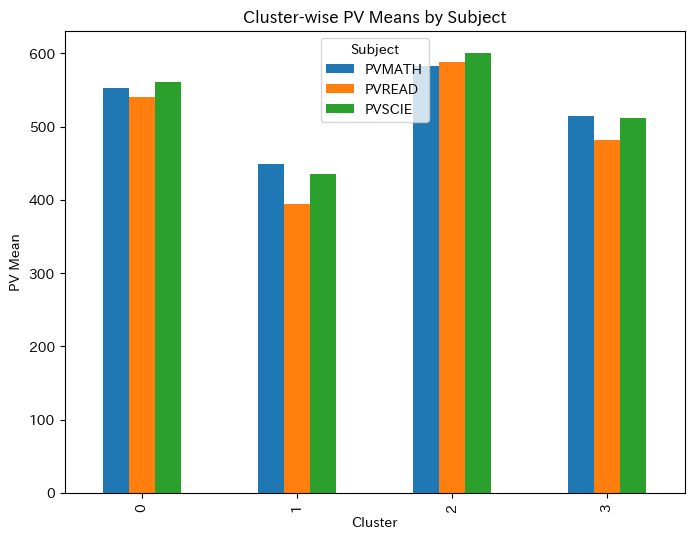

In [44]:
df_subject_means.plot(kind="bar", figsize=(8, 6))
plt.title("Cluster-wise PV Means by Subject")
plt.xlabel("Cluster")
plt.ylabel("PV Mean")
plt.legend(title="Subject")
plt.show()
